In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [7]:
# df_sissi = pd.DataFrame(pd.read_excel("D:/Masterarbeit/Data/RNAz_Data_di_Excel/sissi.xlsx"))
# df_sissiz_mono = pd.DataFrame(pd.read_excel("D:/Masterarbeit/Data/RNAz_Data_di_Excel/sissiz_mono.xlsx"))
# df_sissiz_di = pd.DataFrame(pd.read_excel("D:/Masterarbeit/Data/RNAz_Data_di_Excel/sissiz_di.xlsx"))
# df_multiperm_mono = pd.DataFrame(pd.read_excel("D:/Masterarbeit/Data/RNAz_Data_di_Excel/multiperm_mono.xlsx"))
# df_multiperm_di = pd.DataFrame(pd.read_excel("D:/Masterarbeit/Data/RNAz_Data_di_Excel/multiperm_di.xlsx"))
# df_alifoldz = pd.DataFrame(pd.read_excel("D:/Masterarbeit/Data/RNAz_Data_di_Excel/alifoldz.xlsx"))

In [8]:
df_sissi = pd.DataFrame(pd.read_excel("C:/bla/Waste/MA/Data/RNAz_Data_di_Excel/sissi.xlsx"))
df_sissiz_mono = pd.DataFrame(pd.read_excel("C:/bla/Waste/MA/Data/RNAz_Data_di_Excel/sissiz_mono.xlsx"))
df_sissiz_di = pd.DataFrame(pd.read_excel("C:/bla/Waste/MA/Data/RNAz_Data_di_Excel/sissiz_di.xlsx"))
df_multiperm_mono = pd.DataFrame(pd.read_excel("C:/bla/Waste/MA/Data/RNAz_Data_di_Excel/multiperm_mono.xlsx"))
df_multiperm_di = pd.DataFrame(pd.read_excel("C:/bla/Waste/MA/Data/RNAz_Data_di_Excel/multiperm_di.xlsx"))
df_alifoldz = pd.DataFrame(pd.read_excel("C:/bla/Waste/MA/Data/RNAz_Data_di_Excel/alifoldz.xlsx"))

In [9]:
new_df_sissi = df_sissi.drop(['Sequences', 'Columns'], axis=1)
new_df_sissi.head(10)

,Mean pairwise identity,Shannon entropy,G+C content,Mean single sequence MFE,Consensus MFE,Energy contribution,Covariance contribution,Combinations/Pair,Mean z-score,Structure conservation index,SVM decision value,SVM RNA-class probability,File
0,88.56,0.33271,0.49297,-158.98,-89.35,-85.71,-3.63,2.35,-48.40,0.56,3.43,0.998643,pos_sample_output_55.txt
1,87.03,0.37237,0.47679,-143.04,-88.69,-83.58,-5.12,2.40,-44.32,0.62,3.19,0.997839,pos_sample_output_89.txt
2,88.15,0.34519,0.50339,-175.00,-109.84,-105.98,-3.86,2.43,-50.59,0.63,3.15,0.997668,pos_sample_output_72.txt
3,88.53,0.33514,0.45837,-142.09,-79.41,-75.35,-4.06,2.37,-55.46,0.56,3.43,0.998645,pos_sample_output_20.txt
4,88.63,0.33170,0.51272,-166.38,-109.89,-105.98,-3.91,2.24,-45.03,0.66,3.01,0.996937,pos_sample_output_97.txt
5,87.80,0.35132,0.49504,-156.16,-100.00,-95.11,-4.88,2.44,-45.29,0.64,3.10,0.997433,pos_sample_output_37.txt
6,87.54,0.36054,0.46915,-151.43,-85.51,-81.01,-4.50,2.49,-51.48,0.56,3.44,0.998660,pos_sample_output_87.txt
7,85.90,0.40009,0.47768,-157.45,-82.41,-77.57,-4.84,2.42,-52.21,0.52,3.58,0.998978,pos_sample_output_12.txt
8,87.78,0.35122,0.44766,-141.66,-80.46,-75.97,-4.50,2.28,-62.70,0.57,3.40,0.998560,pos_sample_output_68.txt
9,88.20,0.34545,0.47778,-157.35,-106.12,-99.98,-6.14,2.48,-50.26,0.67,2.95,0.996570,pos_sample_output_11.txt


In [10]:
new_df_sissi[['Mean pairwise identity',
        'Shannon entropy','G+C content',
        'Mean single sequence MFE',	
        'Consensus MFE','Energy contribution',
        'Covariance contribution',
        'Combinations/Pair',
        'Mean z-score',
        'Structure conservation index',
        'SVM decision value',
        'SVM RNA-class probability']].describe()

,Mean pairwise identity,Shannon entropy,G+C content,Mean single sequence MFE,Consensus MFE,Energy contribution,Covariance contribution,Combinations/Pair,Mean z-score,Structure conservation index,SVM decision value,SVM RNA-class probability
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,87.445100,0.361246,0.488293,-156.546600,-89.324900,-84.676400,-4.648700,2.416200,-49.381700,0.569700,3.365300,0.998253
std,0.756851,0.017965,0.026755,10.126071,12.603013,12.269277,1.030818,0.081213,6.743834,0.063619,0.241797,0.001126
min,84.960000,0.326170,0.421830,-176.760000,-129.810000,-124.680000,-7.340000,2.110000,-73.220000,0.390000,2.470000,0.991373
25%,86.980000,0.348790,0.469832,-162.980000,-97.665000,-92.587500,-5.152500,2.367500,-52.232500,0.530000,3.240000,0.998037
50%,87.505000,0.360565,0.487960,-157.570000,-88.920000,-84.910000,-4.650000,2.420000,-47.415000,0.570000,3.400000,0.998568
75%,87.977500,0.372213,0.507380,-148.492500,-80.692500,-76.052500,-3.900000,2.472500,-44.637500,0.610000,3.532500,0.998891
max,88.900000,0.419530,0.546100,-131.740000,-56.810000,-53.500000,-1.970000,2.590000,-39.750000,0.750000,3.770000,0.999289


In [11]:
new_df_sissiz_mono = df_sissiz_mono.drop(['Sequences', 'Columns'], axis=1)
new_df_sissiz_mono.head(10)

,Mean pairwise identity,Shannon entropy,G+C content,Mean single sequence MFE,Consensus MFE,Energy contribution,Covariance contribution,Combinations/Pair,Mean z-score,Structure conservation index,SVM decision value,SVM RNA-class probability,File
0,87.36,0.37518,0.51269,-136.55,-10.02,-10.13,0.10,1.52,-29.77,0.07,2.71,0.994587,neg_sample_SISSIz_mono_output_60_175.txt
1,87.92,0.36275,0.43286,-107.94,-4.15,-4.12,-0.02,1.83,-41.30,0.04,2.51,0.992039,neg_sample_SISSIz_mono_output_20_322.txt
2,86.91,0.39075,0.47666,-115.96,-7.61,-7.62,0.02,1.53,-28.73,0.07,2.74,0.994891,neg_sample_SISSIz_mono_output_88_522.txt
3,84.13,0.45984,0.52967,-141.22,-11.09,-10.90,-0.19,1.60,-30.88,0.08,2.94,0.996513,neg_sample_SISSIz_mono_output_23_838.txt
4,86.83,0.38939,0.45898,-118.85,-4.08,-3.94,-0.14,1.84,-39.99,0.03,2.50,0.991894,neg_sample_SISSIz_mono_output_62_322.txt
5,86.49,0.39543,0.54115,-144.52,-15.89,-15.93,0.04,1.50,-32.28,0.11,2.97,0.996715,neg_sample_SISSIz_mono_output_65_491.txt
6,86.29,0.40771,0.46240,-117.68,-5.90,-6.00,0.10,1.54,-36.09,0.05,2.66,0.994007,neg_sample_SISSIz_mono_output_38_840.txt
7,87.46,0.37056,0.48130,-119.89,-18.99,-18.95,-0.04,1.53,-29.58,0.16,3.17,0.997768,neg_sample_SISSIz_mono_output_33_485.txt
8,86.96,0.38667,0.49207,-132.15,-8.10,-8.06,-0.04,1.52,-34.36,0.06,2.68,0.994201,neg_sample_SISSIz_mono_output_16_182.txt
9,85.33,0.42585,0.47145,-108.56,-5.19,-5.02,-0.16,1.69,-25.77,0.05,2.70,0.994421,neg_sample_SISSIz_mono_output_47_686.txt


In [12]:
new_df_sissiz_mono[['Mean pairwise identity',
        'Shannon entropy','G+C content',
        'Mean single sequence MFE',	
        'Consensus MFE','Energy contribution',
        'Covariance contribution',
        'Combinations/Pair',
        'Mean z-score',
        'Structure conservation index',
        'SVM decision value',
        'SVM RNA-class probability']].describe()

,Mean pairwise identity,Shannon entropy,G+C content,Mean single sequence MFE,Consensus MFE,Energy contribution,Covariance contribution,Combinations/Pair,Mean z-score,Structure conservation index,SVM decision value,SVM RNA-class probability
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,86.583645,0.395997,0.488262,-126.134666,-8.969149,-9.000053,0.030955,1.573494,-33.062698,0.070079,2.747887,0.994645
std,0.904675,0.022921,0.035077,11.694756,4.271175,4.285494,0.253405,0.176617,5.399544,0.030967,0.177123,0.007878
min,82.760000,0.328120,0.350310,-175.700000,-28.990000,-28.960000,-1.020000,0.000000,-54.200000,-0.000000,-5.750000,0.000015
25%,85.990000,0.379720,0.464670,-133.980000,-11.620000,-11.680000,-0.080000,1.470000,-35.680000,0.050000,2.630000,0.993706
50%,86.630000,0.394930,0.488940,-126.070000,-8.590000,-8.620000,0.020000,1.570000,-31.910000,0.070000,2.740000,0.994891
75%,87.220000,0.410950,0.512150,-118.200000,-5.850000,-5.880000,0.100000,1.680000,-29.340000,0.090000,2.860000,0.995906
max,89.260000,0.496620,0.611770,-82.370000,0.000000,0.060000,3.100000,2.250000,-1.550000,0.200000,3.390000,0.998523


In [13]:
new_df_sissiz_di = df_sissiz_di.drop(['Sequences', 'Columns'], axis=1)
new_df_sissiz_di.head(10)

,Mean pairwise identity,Shannon entropy,G+C content,Mean single sequence MFE,Consensus MFE,Energy contribution,Covariance contribution,Combinations/Pair,Mean z-score,Structure conservation index,SVM decision value,SVM RNA-class probability,File
0,86.85,0.38935,0.49703,-133.62,-13.98,-13.73,-0.25,2.07,-32.56,0.10,2.91,0.996278,neg_sample_SISSIz_di_output_7_471.txt
1,88.05,0.35980,0.53501,-142.31,-13.16,-13.35,0.19,1.50,-31.36,0.09,2.80,0.995395,neg_sample_SISSIz_di_output_69_45.txt
2,84.93,0.43806,0.49194,-131.85,-11.54,-11.93,0.38,1.77,-33.58,0.09,2.95,0.996571,neg_sample_SISSIz_di_output_76_235.txt
3,86.67,0.38942,0.47669,-118.53,-7.35,-7.40,0.05,1.56,-30.10,0.06,2.68,0.994260,neg_sample_SISSIz_di_output_48_902.txt
4,87.11,0.37974,0.53293,-141.75,-16.40,-16.12,-0.28,1.58,-31.31,0.12,2.99,0.996854,neg_sample_SISSIz_di_output_9_815.txt
5,86.11,0.41100,0.48254,-122.43,-13.53,-13.69,0.16,1.66,-31.44,0.11,3.00,0.996901,neg_sample_SISSIz_di_output_29_568.txt
6,87.03,0.38615,0.52363,-144.79,-18.36,-18.48,0.12,1.77,-32.63,0.13,3.06,0.997212,neg_sample_SISSIz_di_output_91_913.txt
7,85.12,0.42915,0.43823,-116.63,-7.75,-7.66,-0.10,1.59,-46.96,0.07,2.82,0.995596,neg_sample_SISSIz_di_output_1_229.txt
8,85.72,0.41673,0.46592,-124.10,-15.30,-15.34,0.04,1.58,-37.66,0.12,3.07,0.997255,neg_sample_SISSIz_di_output_92_765.txt
9,85.76,0.41956,0.48760,-127.29,-2.35,-2.52,0.17,1.53,-33.40,0.02,2.50,0.991891,neg_sample_SISSIz_di_output_73_895.txt


In [14]:
new_df_sissiz_di[['Mean pairwise identity',
        'Shannon entropy','G+C content',
        'Mean single sequence MFE',	
        'Consensus MFE','Energy contribution',
        'Covariance contribution',
        'Combinations/Pair',
        'Mean z-score',
        'Structure conservation index',
        'SVM decision value',
        'SVM RNA-class probability']].describe()

,Mean pairwise identity,Shannon entropy,G+C content,Mean single sequence MFE,Consensus MFE,Energy contribution,Covariance contribution,Combinations/Pair,Mean z-score,Structure conservation index,SVM decision value,SVM RNA-class probability
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,86.489937,0.396897,0.489271,-127.909001,-10.406722,-10.429899,0.023176,1.571912,-33.766457,0.080605,2.808834,0.995254
std,0.909399,0.022964,0.035767,12.185140,4.568141,4.576527,0.239987,0.154548,5.327307,0.033072,0.173061,0.002037
min,82.670000,0.327300,0.354270,-176.750000,-33.090000,-34.800000,-0.960000,0.000000,-55.000000,0.000000,0.750000,0.806883
25%,85.900000,0.380610,0.465090,-135.940000,-13.260000,-13.270000,-0.080000,1.470000,-36.340000,0.060000,2.690000,0.994318
50%,86.530000,0.395900,0.489640,-127.730000,-9.990000,-10.015000,0.020000,1.570000,-32.620000,0.080000,2.800000,0.995452
75%,87.140000,0.411740,0.513620,-119.530000,-7.110000,-7.150000,0.110000,1.670000,-30.090000,0.100000,2.920000,0.996396
max,89.370000,0.498870,0.617690,-81.330000,0.000000,0.000000,2.840000,2.570000,-4.370000,0.240000,3.490000,0.998779


In [15]:
new_df_multiperm_mono = df_multiperm_mono.drop(['Sequences', 'Columns'], axis=1)
new_df_multiperm_mono.head(10)

,Mean pairwise identity,Shannon entropy,G+C content,Mean single sequence MFE,Consensus MFE,Energy contribution,Covariance contribution,Combinations/Pair,Mean z-score,Structure conservation index,SVM decision value,SVM RNA-class probability,File
0,86.90,0.37424,0.45102,-117.45,-28.05,-26.11,-1.94,2.16,-43.84,0.24,3.49,0.998797,neg_sample_MULTIPERM_mono_output_39_770.txt
1,84.96,0.41953,0.51810,-138.85,-33.47,-31.93,-1.54,2.17,-30.34,0.24,3.57,0.998959,neg_sample_MULTIPERM_mono_output_23_824.txt
2,86.42,0.38677,0.50003,-134.83,-32.13,-29.33,-2.80,2.15,-32.92,0.24,3.51,0.998844,neg_sample_MULTIPERM_mono_output_2_971.txt
3,88.15,0.34519,0.50339,-135.98,-40.22,-37.64,-2.58,2.19,-31.07,0.30,3.61,0.999035,neg_sample_MULTIPERM_mono_output_72_12.txt
4,87.30,0.36575,0.46851,-120.46,-28.17,-26.07,-2.10,2.13,-33.60,0.23,3.45,0.998682,neg_sample_MULTIPERM_mono_output_29_441.txt
5,87.65,0.36130,0.48686,-120.49,-23.78,-23.05,-0.74,2.00,-29.47,0.20,3.33,0.998345,neg_sample_MULTIPERM_mono_output_34_847.txt
6,87.26,0.36244,0.50246,-137.35,-31.03,-29.79,-1.24,2.11,-33.23,0.23,3.44,0.998668,neg_sample_MULTIPERM_mono_output_5_384.txt
7,88.40,0.34376,0.45671,-122.89,-24.09,-23.18,-0.91,2.13,-43.18,0.20,3.30,0.998245,neg_sample_MULTIPERM_mono_output_58_446.txt
8,86.98,0.37106,0.50774,-131.52,-36.26,-33.85,-2.42,2.18,-28.11,0.28,3.60,0.999024,neg_sample_MULTIPERM_mono_output_41_976.txt
9,86.98,0.37106,0.50774,-137.49,-34.90,-32.49,-2.41,2.09,-31.08,0.25,3.52,0.998856,neg_sample_MULTIPERM_mono_output_41_304.txt


In [16]:
new_df_multiperm_mono[['Mean pairwise identity',
        'Shannon entropy','G+C content',
        'Mean single sequence MFE',	
        'Consensus MFE','Energy contribution',
        'Covariance contribution',
        'Combinations/Pair',
        'Mean z-score',
        'Structure conservation index',
        'SVM decision value',
        'SVM RNA-class probability']].describe()

,Mean pairwise identity,Shannon entropy,G+C content,Mean single sequence MFE,Consensus MFE,Energy contribution,Covariance contribution,Combinations/Pair,Mean z-score,Structure conservation index,SVM decision value,SVM RNA-class probability
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,87.445100,0.361246,0.488293,-128.426400,-29.865833,-28.475634,-1.390208,2.089866,-33.925208,0.231267,3.424215,0.998566
std,0.753061,0.017875,0.026621,9.106133,7.007184,6.861303,0.528018,0.075817,4.536665,0.046243,0.146789,0.000444
min,84.960000,0.326170,0.421830,-163.820000,-60.630000,-59.710000,-3.860000,1.710000,-54.450000,0.070000,2.720000,0.994699
25%,86.980000,0.348790,0.469832,-134.700000,-34.730000,-33.240000,-1.710000,2.040000,-35.750000,0.200000,3.330000,0.998355
50%,87.505000,0.360565,0.487960,-128.570000,-29.600000,-28.180000,-1.380000,2.090000,-32.880000,0.230000,3.440000,0.998665
75%,87.977500,0.372213,0.507380,-122.100000,-24.710000,-23.430000,-1.080000,2.140000,-30.800000,0.260000,3.530000,0.998887
max,88.900000,0.419530,0.546100,-97.820000,-8.130000,-7.280000,2.830000,2.490000,-23.480000,0.450000,3.750000,0.999260


In [17]:
new_df_multiperm_di = df_multiperm_di.drop(['Sequences', 'Columns'], axis=1)
new_df_multiperm_di.head(10)

,Mean pairwise identity,Shannon entropy,G+C content,Mean single sequence MFE,Consensus MFE,Energy contribution,Covariance contribution,Combinations/Pair,Mean z-score,Structure conservation index,SVM decision value,SVM RNA-class probability,File
0,87.97,0.35164,0.46796,-118.68,-25.67,-24.42,-1.25,2.15,-34.09,0.22,3.39,0.998524,neg_sample_MULTIPERM_di_output_70_754.txt
1,87.23,0.36508,0.49249,-131.86,-32.51,-30.88,-1.63,2.07,-33.46,0.25,3.51,0.998834,neg_sample_MULTIPERM_di_output_26_529.txt
2,87.23,0.36508,0.49249,-131.18,-31.11,-29.79,-1.32,2.11,-33.11,0.24,3.48,0.998762,neg_sample_MULTIPERM_di_output_26_917.txt
3,87.59,0.35746,0.49412,-130.00,-30.06,-28.78,-1.28,2.08,-31.64,0.23,3.43,0.998647,neg_sample_MULTIPERM_di_output_27_914.txt
4,88.05,0.34423,0.48891,-126.55,-40.96,-39.96,-1.00,2.00,-31.55,0.32,3.64,0.999101,neg_sample_MULTIPERM_di_output_59_636.txt
5,86.56,0.37724,0.51915,-136.08,-37.56,-35.24,-2.32,2.09,-29.01,0.28,3.61,0.999041,neg_sample_MULTIPERM_di_output_25_533.txt
6,87.68,0.35528,0.46988,-125.30,-28.74,-27.63,-1.11,2.08,-37.27,0.23,3.43,0.998637,neg_sample_MULTIPERM_di_output_18_951.txt
7,86.30,0.38886,0.43283,-114.97,-20.77,-19.66,-1.11,2.16,-45.35,0.18,3.29,0.998234,neg_sample_MULTIPERM_di_output_1_640.txt
8,87.82,0.34907,0.51304,-137.88,-37.74,-35.76,-1.98,2.06,-30.55,0.27,3.54,0.998904,neg_sample_MULTIPERM_di_output_53_982.txt
9,87.61,0.35554,0.50441,-134.56,-44.10,-41.60,-2.50,2.09,-30.98,0.33,3.68,0.999155,neg_sample_MULTIPERM_di_output_43_201.txt


In [18]:
new_df_multiperm_di[['Mean pairwise identity',
        'Shannon entropy','G+C content',
        'Mean single sequence MFE',	
        'Consensus MFE','Energy contribution',
        'Covariance contribution',
        'Combinations/Pair',
        'Mean z-score',
        'Structure conservation index',
        'SVM decision value',
        'SVM RNA-class probability']].describe()

,Mean pairwise identity,Shannon entropy,G+C content,Mean single sequence MFE,Consensus MFE,Energy contribution,Covariance contribution,Combinations/Pair,Mean z-score,Structure conservation index,SVM decision value,SVM RNA-class probability
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,87.445100,0.361246,0.488293,-128.353818,-29.847004,-28.456351,-1.390638,2.086059,-33.886575,0.231205,3.423296,0.998563
std,0.753061,0.017875,0.026621,9.076811,7.111519,6.973738,0.525951,0.076498,4.548805,0.047103,0.148129,0.000446
min,84.960000,0.326170,0.421830,-161.640000,-59.860000,-58.470000,-3.850000,1.710000,-56.680000,0.060000,2.690000,0.994327
25%,86.980000,0.348790,0.469832,-134.550000,-34.830000,-33.330000,-1.710000,2.040000,-35.700000,0.200000,3.320000,0.998327
50%,87.505000,0.360565,0.487960,-128.460000,-29.590000,-28.180000,-1.380000,2.090000,-32.830000,0.230000,3.440000,0.998658
75%,87.977500,0.372213,0.507380,-122.120000,-24.530000,-23.250000,-1.080000,2.140000,-30.760000,0.260000,3.530000,0.998888
max,88.900000,0.419530,0.546100,-99.900000,-6.890000,-6.270000,3.520000,2.450000,-23.960000,0.450000,3.750000,0.999261


In [19]:
new_df_alifoldz = df_alifoldz.drop(['Sequences', 'Columns', 'File'], axis=1)
new_df_alifoldz.head(10)

,Mean pairwise identity,Shannon entropy,G+C content,Mean single sequence MFE,Consensus MFE,Energy contribution,Covariance contribution,Combinations/Pair,Mean z-score,Structure conservation index,SVM decision value,SVM RNA-class probability
0,87.61,0.35554,0.50441,-138.94,-66.62,-63.02,-3.61,2.23,-33.19,0.48,3.65,0.999110
1,87.24,0.36982,0.47497,-131.83,-38.87,-35.94,-2.92,2.37,-37.27,0.29,3.62,0.999063
2,87.49,0.36246,0.48715,-140.74,-49.14,-47.12,-2.02,2.32,-39.48,0.35,3.71,0.999208
3,86.21,0.39250,0.45582,-129.61,-33.70,-31.22,-2.49,2.38,-49.15,0.26,3.58,0.998988
4,87.36,0.36696,0.46256,-119.30,-45.16,-43.23,-1.93,2.34,-37.31,0.38,3.74,0.999246
5,86.00,0.39443,0.46835,-116.31,-27.79,-26.55,-1.25,2.28,-32.16,0.24,3.53,0.998872
6,88.73,0.32721,0.48063,-130.92,-59.13,-56.20,-2.94,2.21,-35.50,0.45,3.67,0.999142
7,87.03,0.37237,0.47679,-125.94,-39.90,-37.14,-2.76,2.31,-35.01,0.32,3.68,0.999168
8,88.20,0.34545,0.47778,-127.93,-53.23,-49.06,-4.18,2.49,-34.50,0.42,3.71,0.999207
9,88.03,0.34795,0.44066,-117.69,-37.64,-35.07,-2.57,2.45,-46.24,0.32,3.65,0.999111


In [20]:
new_df_alifoldz[['Mean pairwise identity',
        'Shannon entropy','G+C content',
        'Mean single sequence MFE',	
        'Consensus MFE','Energy contribution',
        'Covariance contribution',
        'Combinations/Pair',
        'Mean z-score',
        'Structure conservation index',
        'SVM decision value',
        'SVM RNA-class probability']].describe()

,Mean pairwise identity,Shannon entropy,G+C content,Mean single sequence MFE,Consensus MFE,Energy contribution,Covariance contribution,Combinations/Pair,Mean z-score,Structure conservation index,SVM decision value,SVM RNA-class probability
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,87.445100,0.361246,0.488293,-135.647423,-52.265821,-49.185115,-3.080733,2.319713,-37.885609,0.383664,3.687537,0.999166
std,0.753061,0.017875,0.026621,9.944092,10.520514,10.105872,0.994986,0.113290,5.195674,0.062894,0.062868,0.000118
min,84.960000,0.326170,0.421830,-171.950000,-94.850000,-90.580000,-7.190000,1.810000,-62.130000,0.140000,3.100000,0.997417
25%,86.980000,0.348790,0.469832,-142.572500,-59.380000,-56.010000,-3.700000,2.250000,-40.140000,0.340000,3.670000,0.999143
50%,87.505000,0.360565,0.487960,-135.950000,-51.950000,-48.850000,-3.030000,2.320000,-36.760000,0.380000,3.700000,0.999198
75%,87.977500,0.372213,0.507380,-128.790000,-44.760000,-41.950000,-2.410000,2.390000,-34.260000,0.430000,3.730000,0.999232
max,88.900000,0.419530,0.546100,-104.530000,-18.790000,-17.560000,1.810000,2.740000,-25.010000,0.630000,3.800000,0.999329


## SVM RNA-class probability

C:\Users\stefanre\AppData\Local\Temp\ipykernel_19604\4043379192.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


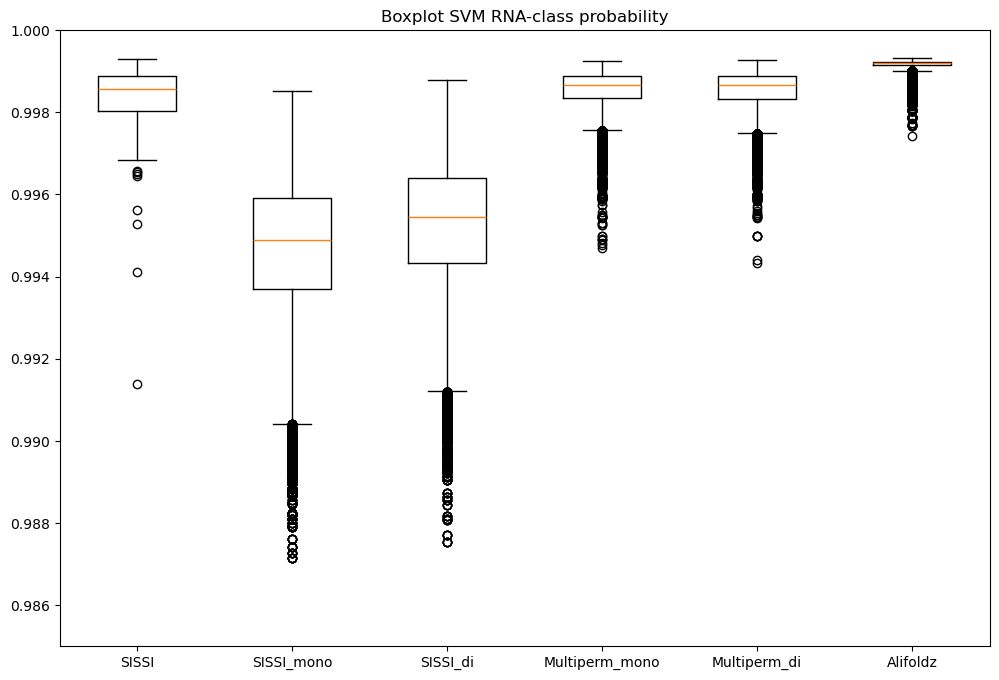

In [21]:
dataframes = [new_df_sissi, new_df_sissiz_mono, new_df_sissiz_di, new_df_multiperm_mono, new_df_multiperm_di, new_df_alifoldz]
labels = ['SISSI', 'SISSI_mono', 'SISSI_di', 'Multiperm_mono', 'Multiperm_di', 'Alifoldz']
data = [df['SVM RNA-class probability'] for df in dataframes]
thresholds = [0.9]

plt.figure(figsize=(12, 8))
plt.boxplot(data, labels=labels)

for t in thresholds:
    plt.axhline(y=t, color='red', linestyle='--', linewidth=1, label=f'Threshold {t}')

plt.ylim(0.985, 1.0)
plt.title('Boxplot SVM RNA-class probability')
plt.show()

## Structure conservation index (SCI)

C:\Users\stefanre\AppData\Local\Temp\ipykernel_19604\2641108522.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


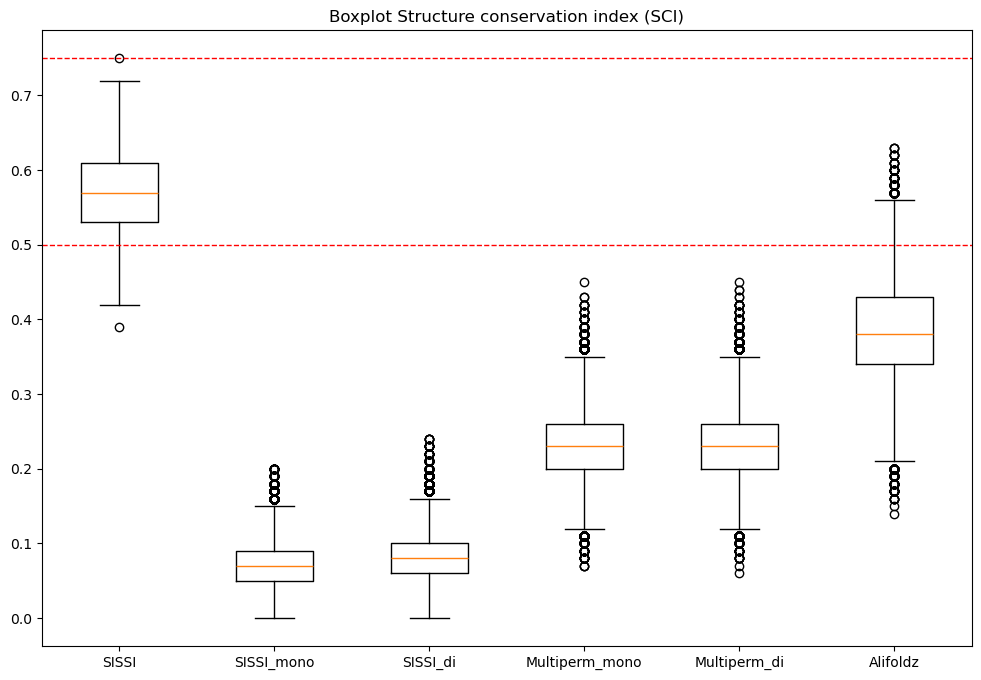

In [22]:
dataframes = [new_df_sissi, new_df_sissiz_mono, new_df_sissiz_di, new_df_multiperm_mono, new_df_multiperm_di, new_df_alifoldz]
labels = ['SISSI', 'SISSI_mono', 'SISSI_di', 'Multiperm_mono', 'Multiperm_di', 'Alifoldz']
data = [df['Structure conservation index'] for df in dataframes]
thresholds = [0.5, 0.75]

plt.figure(figsize=(12, 8))
plt.boxplot(data, labels=labels)

for t in thresholds:
    plt.axhline(y=t, color='red', linestyle='--', linewidth=1, label=f'Threshold {t}')

plt.title('Boxplot Structure conservation index (SCI)')
plt.show()


## Mean z-score

C:\Users\stefanre\AppData\Local\Temp\ipykernel_19604\1821403016.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


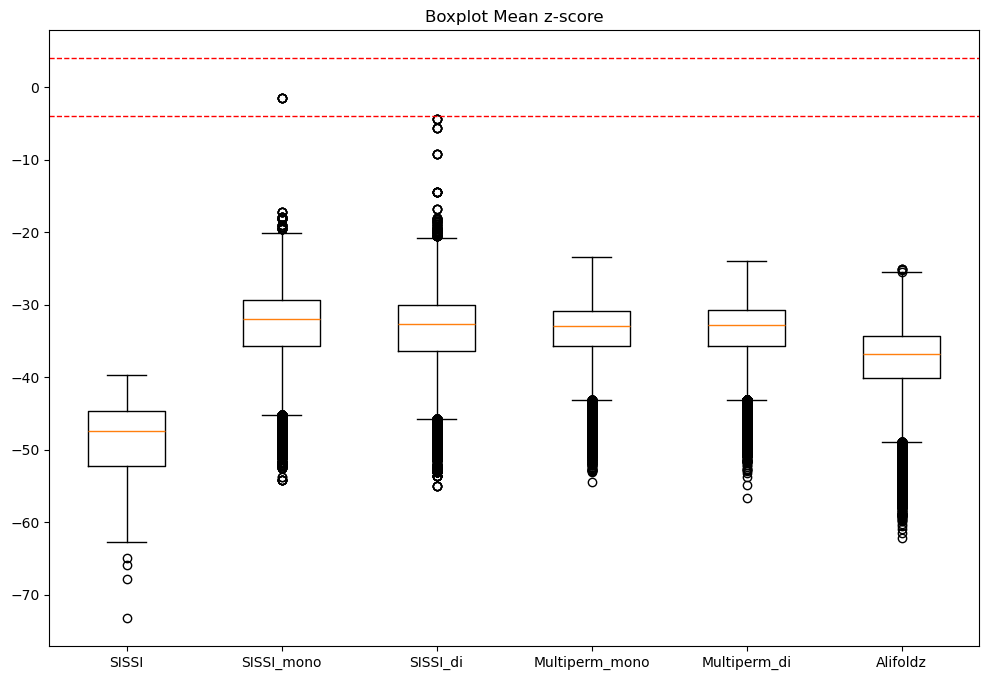

In [23]:
dataframes = [new_df_sissi, new_df_sissiz_mono, new_df_sissiz_di, new_df_multiperm_mono, new_df_multiperm_di, new_df_alifoldz]
labels = ['SISSI', 'SISSI_mono', 'SISSI_di', 'Multiperm_mono', 'Multiperm_di', 'Alifoldz']
data = [df['Mean z-score'] for df in dataframes]
thresholds = [-4, 4]

plt.figure(figsize=(12, 8))
plt.boxplot(data, labels=labels)

for t in thresholds:
    plt.axhline(y=t, color='red', linestyle='--', linewidth=1, label=f'Threshold {t}')

plt.title('Boxplot Mean z-score')
plt.show()

## Consensus MFE

C:\Users\stefanre\AppData\Local\Temp\ipykernel_19604\757403887.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


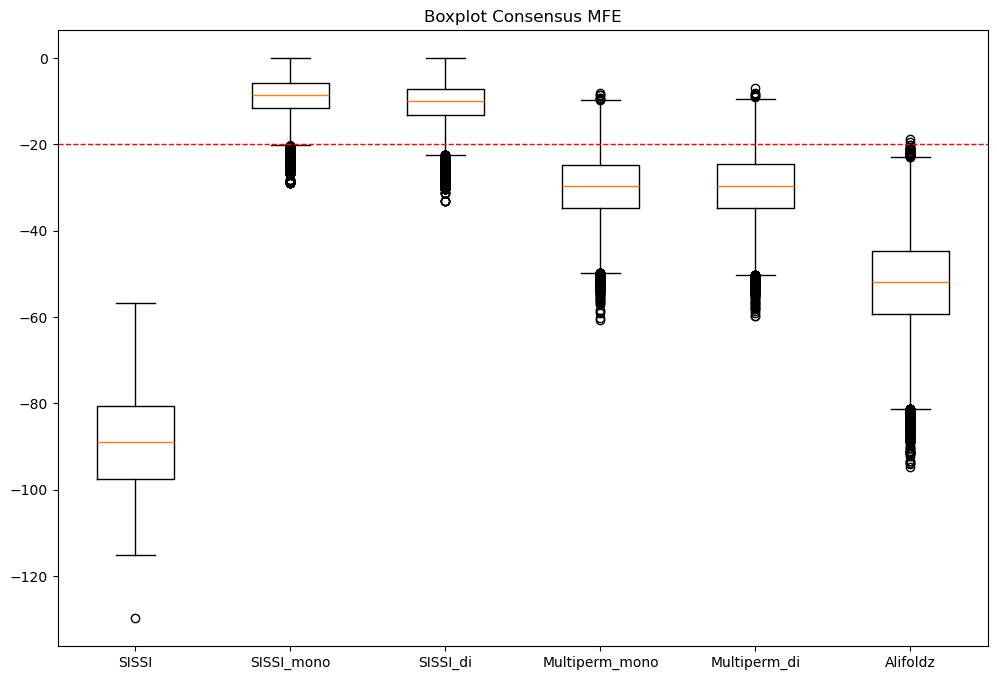

In [24]:
dataframes = [new_df_sissi, new_df_sissiz_mono, new_df_sissiz_di, new_df_multiperm_mono, new_df_multiperm_di, new_df_alifoldz]
labels = ['SISSI', 'SISSI_mono', 'SISSI_di', 'Multiperm_mono', 'Multiperm_di', 'Alifoldz']
data = [df['Consensus MFE'] for df in dataframes]
thresholds = [-20]

plt.figure(figsize=(12, 8))
plt.boxplot(data, labels=labels)

for t in thresholds:
    plt.axhline(y=t, color='red', linestyle='--', linewidth=1, label=f'Threshold {t}')

plt.title('Boxplot Consensus MFE')
plt.show()

## Mean pairwise identity

C:\Users\stefanre\AppData\Local\Temp\ipykernel_19604\1006135273.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


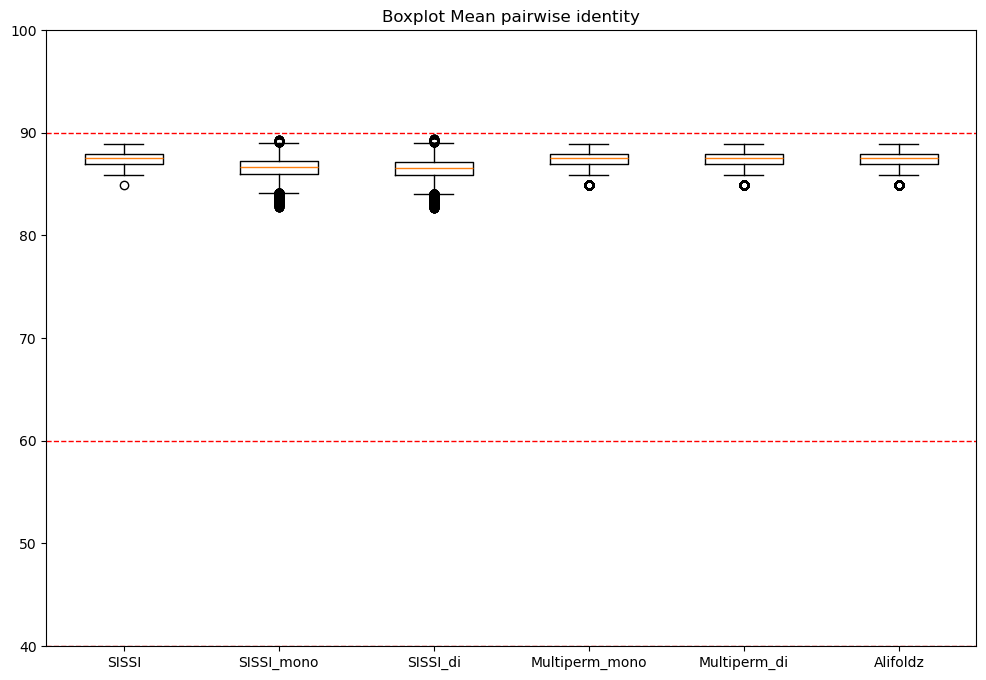

In [25]:
dataframes = [new_df_sissi, new_df_sissiz_mono, new_df_sissiz_di, new_df_multiperm_mono, new_df_multiperm_di, new_df_alifoldz]
labels = ['SISSI', 'SISSI_mono', 'SISSI_di', 'Multiperm_mono', 'Multiperm_di', 'Alifoldz']
data = [df['Mean pairwise identity'] for df in dataframes]
thresholds = [40, 60, 90]

plt.figure(figsize=(12, 8))
plt.boxplot(data, labels=labels)

for t in thresholds:
    plt.axhline(y=t, color='red', linestyle='--', linewidth=1, label=f'Threshold {t}')

plt.ylim(40, 100)
plt.title('Boxplot Mean pairwise identity')
plt.show()